In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# PaddleOCR 3.x yêu cầu PaddlePaddle 3.0+
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/
!python -m pip install "paddleocr[all]"
!pip install ultralytics -q

In [ ]:
import importlib, sys

# Xóa cache module cũ nếu đã import trước đó
if 'container_detector' in sys.modules:
    del sys.modules['container_detector']

import sys
sys.path.append('/content/drive/MyDrive/CODE UNIVERSITY/AIB3')

from container_detector import ContainerDetector
print('✅ Import thành công')

✅ Import thành công


/content/drive/MyDrive/CODE UNIVERSITY/AIB3/container_detector.py:508: SyntaxWarning: invalid escape sequence '\d'
  


Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


[ContainerDetector] Loading YOLO model: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs/container_detector/weights/best.pt
[ContainerDetector] Loading PaddleOCR 3.x (PP-OCRv5 server — high accuracy)...


Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


[ContainerDetector] ✅ Ready
[Orient] bbox 574x91 → HORIZONTAL
[OCR] region_tokens (horizontal): [('45G1', '1.00'), ('13580', '0.23'), ('E', '0.19'), ('AOSE', '0.14')]
[NoiseFilter] skip type-code: '45G1'
[NoiseFilter] skip lone-letter: 'E'
[Horizontal] 1 line(s):
  Line 0: ['AOSE', '13580']
[Fallback-4] Crop horizontal: (795,89)→(1920,362) size=1125x273
[Fallback-4] variant 0 tokens: MSCU 45G1 983672 3
[NoiseFilter] skip type-code: '45G1'
[Fallback-4] After noise filter: MSCU 983672 3
[Fallback-4] ✅ Strategy-B (noise-filtered): MSCU9836723
[Orient] bbox 494x78 → HORIZONTAL
[OCR] region_tokens (horizontal): [('165109', '1.00'), ('22G1', '1.00'), ('TCKU', '0.98')]
[NoiseFilter] skip type-code: '22G1'
[Horizontal] 1 line(s):
  Line 0: ['TCKU', '165109']
[Parse] Priority-2H (line): 'TCKU 165109'
[CheckDigit] computed ISO 6346: 7
[Orient] bbox 71x653 → VERTICAL
[OCR] region_tokens (vertical): [('9.8', '0.96'), ('DRYU254566T', '0.92'), ('IGZZ', '0.67'), ('回', '0.54'), ('0L', '0.43'), ('8s', 

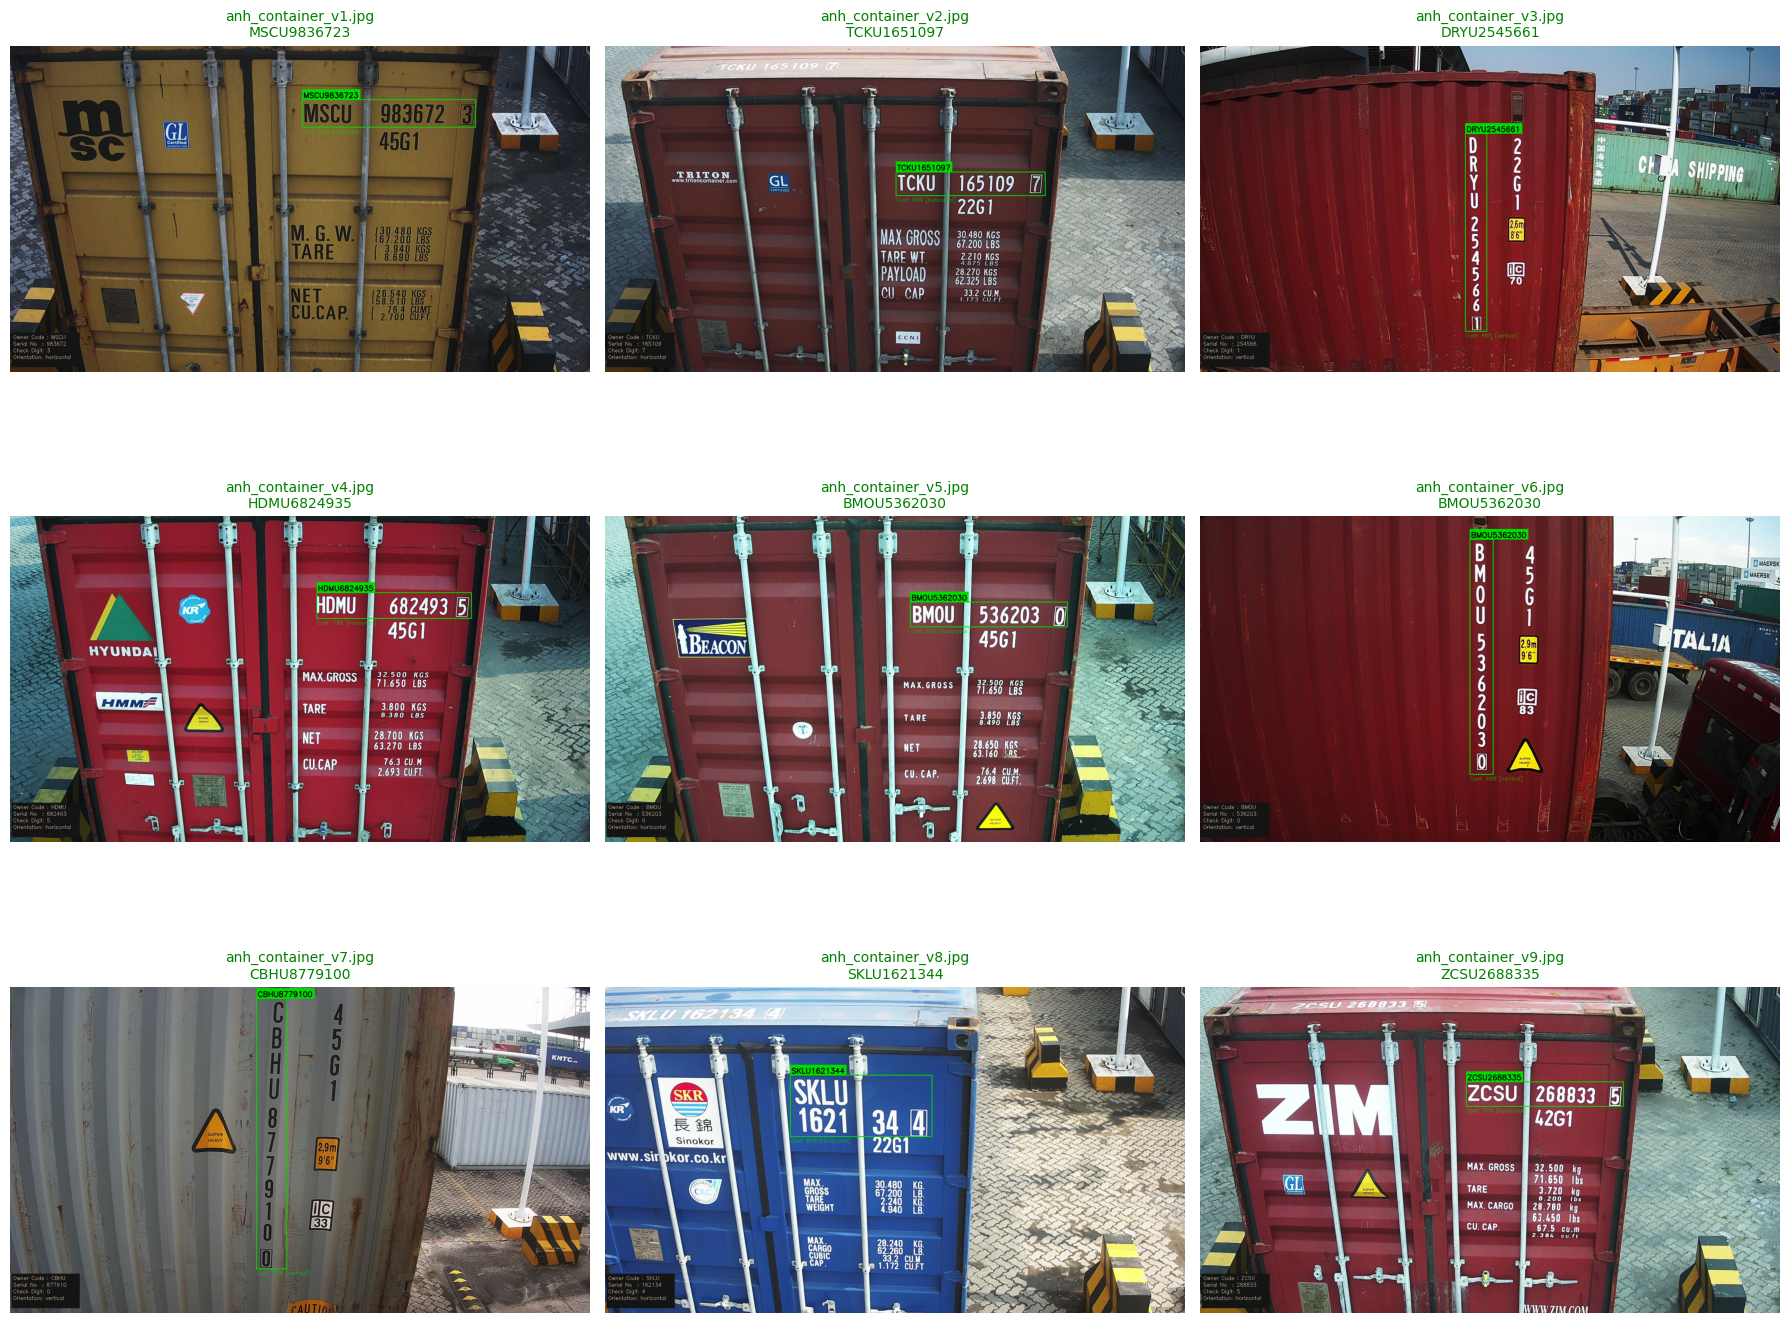

In [ ]:
import glob
import matplotlib.pyplot as plt
import cv2

# ── Cấu hình ──────────────────────────────────────────────
BASE = '/content/drive/MyDrive/CODE UNIVERSITY/AIB3'

# Thêm/bớt ảnh tùy ý
# image_paths = sorted(glob.glob(f'{BASE}/anh_container*.jpg'))
image_paths = [
    f'{BASE}/anh_container_v1.jpg',
    f'{BASE}/anh_container_v2.jpg',
     f'{BASE}/anh_container_v3.jpg',
    f'{BASE}/anh_container_v4.jpg',
     f'{BASE}/anh_container_v5.jpg',
    f'{BASE}/anh_container_v6.jpg',
     f'{BASE}/anh_container_v7.jpg',
    f'{BASE}/anh_container_v8.jpg',
     f'{BASE}/anh_container_v9.jpg'
]

# ── Load detector 1 lần duy nhất ──────────────────────────
detector = ContainerDetector(
    model_path=f'{BASE}/runs/container_detector/weights/best.pt'
)

# ── Chạy tất cả ảnh ───────────────────────────────────────
results = []
for path in image_paths:
    result, annotated = detector.detect_image(path)
    results.append((path, result, annotated))

# ── In bảng tổng hợp ──────────────────────────────────────
print('='*65)
print(f'  {"Ảnh":<20} {"Status":<10} {"Full Number":<15} {"Conf":>6}')
print('='*65)
for path, r, _ in results:
    name = path.split('/')[-1]
    print(f'  {name:<20} {r.status:<10} {r.full_number or "—":<15} {r.confidence:>6.1%}')
print('='*65)

# ── Hiển thị tất cả ảnh annotated ─────────────────────────
n = len(results)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, (path, r, annotated) in enumerate(results):
    name = path.split('/')[-1]
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[i].axis('off')
    color = 'green' if r.status == 'FOUND' else 'orange' if r.status == 'PARTIAL' else 'red'
    axes[i].set_title(f'{name}\n{r.full_number or r.status}', color=color, fontsize=10)

# Ẩn các ô thừa
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


[ContainerDetector] Loading YOLO model: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs/container_detector/weights/best.pt
[ContainerDetector] Loading PaddleOCR 3.x (PP-OCRv5 server — high accuracy)...


Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


[ContainerDetector] ✅ Ready
[Orient] bbox 574x91 → HORIZONTAL
[OCR] region_tokens (horizontal): [('45G1', '1.00'), ('13580', '0.23'), ('E', '0.19'), ('AOSE', '0.14')]
[NoiseFilter] skip type-code: '45G1'
[NoiseFilter] skip lone-letter: 'E'
[Horizontal] 1 line(s):
  Line 0: ['AOSE', '13580']
[Fallback-4] Crop horizontal: (795,89)→(1920,362) size=1125x273
[Fallback-4] variant 0 tokens: MSCU 45G1 983672 3
[NoiseFilter] skip type-code: '45G1'
[Fallback-4] After noise filter: MSCU 983672 3
[Fallback-4] ✅ Strategy-B (noise-filtered): MSCU9836723
  CONTAINER NUMBER DETECTION RESULT
  Status       : FOUND
  Full Number  : MSCU9836723
  Owner Code   : MSCU
  Serial Number: 983672
  Check Digit  : 3
  Confidence   : 79.87%
  Raw OCR      : 45G1 13580 E AOSE


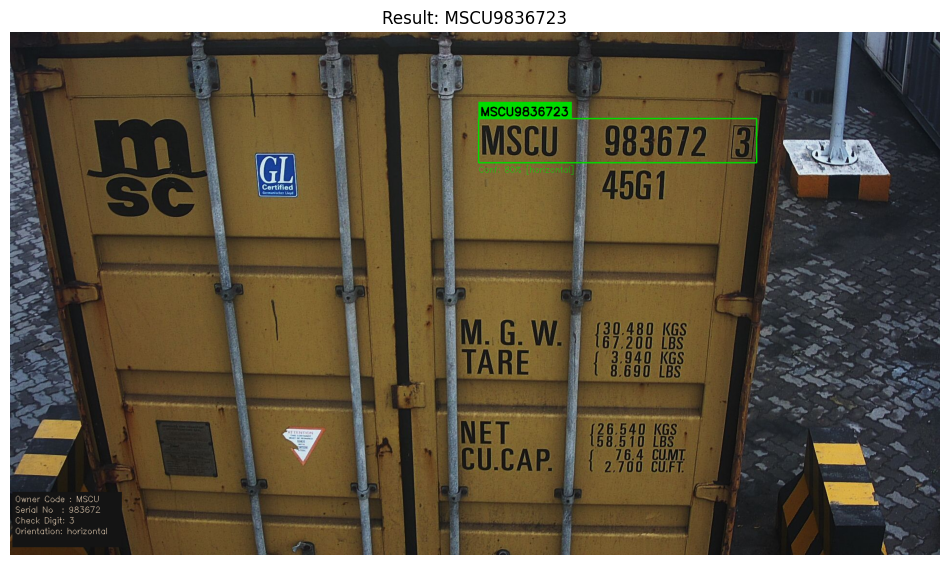

In [ ]:
test_image = '/content/drive/MyDrive/CODE UNIVERSITY/AIB3/anh_container_v1.jpg'

detector = ContainerDetector(
    model_path='/content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs/container_detector/weights/best.pt'
)

result, annotated = detector.detect_image(test_image)

print('='*45)
print('  CONTAINER NUMBER DETECTION RESULT')
print('='*45)
print(f'  Status       : {result.status}')
print(f'  Full Number  : {result.full_number or "—"}')
print(f'  Owner Code   : {result.owner_code or "—"}')
print(f'  Serial Number: {result.serial_number or "—"}')
print(f'  Check Digit  : {result.check_digit or "—"}')
print(f'  Confidence   : {result.confidence:.2%}')
print(f'  Raw OCR      : {result.raw_ocr_text}')
print('='*45)
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Result: {result.full_number or result.status}')
plt.show()